# Assignment 1: Supervised Learning

**Course:** Machine Learning Fundamentals

**Total Points:** 100 (To be Scaled)

## General Instructions

1.  **Datasets**
    *   `server_performance_student.csv`: For regression analysis.
    *   `fraud_detection_student.csv`: For classification analysis.

2.  **Submission**
    *   Submit this `.ipynb` file only.
    *   Do not modify function signatures.
    *   Ensure all code cells run successfully.
    *   Do not hardcode the numbers in the returned dictionary
    *   Please do not include any commands like `!pip install numpy` because they may break the conversion process and therefore the submission will not be graded.
  
   - **File Naming Convention:**  
  - Use **your university email as the filename**, e.g.,  
    ```
    j.doe@innopolis.university.ipynb
    ```
  - **Do NOT modify this format**, or your submission may not be graded.

🔹 **Assignment Breakdown:**
| Task | Description | Points |
|------|------------|--------|
| **Task 1.1** | Linear and Polynomial Regression | 30 |
| **Task 2.1** | Data Preprocessing | 20 |
| **Task 2.2** | Classificaiton | 30 |
| **Task 2.3** | Thresholding | 20 |
| **Total** | - | **100** |

---

3.  **Grading**
    *   Your code will be graded automatically.
    *   **Requirement:** You must use `random_state=2026` for all data splitting and model initialization.

## Required Libraries

In [1]:
import pandas as pd
import numpy as np
from typing import Dict, Tuple, Any

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import f1_score, recall_score, precision_score

# GLOBAL RANDOM STATE
RANDOM_STATE = 2026

In [2]:
# my imported libraries
from sklearn.metrics import root_mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

## Task 1: Regression (30 Points)

**Objective:** Predict server latency based on concurrent requests.

**Requirements:**
1.  Load `server_performance_student.csv`.
2.  Split the data into Training (80%) and Testing (20%) sets using `random_state=2026`.
3.  Train a **Linear Regression** model.
4. plot the data to analyze and  see why your Linear model fail?
4.  Train a **Polynomial Regression** model using `GridSearchCV` to find the optimal degree (search range: 2 to 5).
5.  Return the metrics in the dictionary format specified below.

**Grading Criteria:**
*   RMSE < 120: Excellent (30/30)
*   RMSE < 180: Very Good (28/30)
*   RMSE < 250: Good (25/30)
*   RMSE < 350: Acceptable (15/30)
*   RMSE ≥ 350: Poor performance

In [3]:
# reading .csv file
df = pd.read_csv('server_performance_student.csv')
df.head()

,Concurrent_Requests,Latency_ms
0,101,31.90
1,951,3091.78
2,441,78.45
3,1299,8147.00
4,70,27.11


In [4]:
# checking Nones -> No Nones
df.isna().sum()

Concurrent_Requests    0
Latency_ms             0
dtype: int64

In [5]:
# information about features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Concurrent_Requests  10000 non-null  int64  
 1   Latency_ms           10000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 156.4 KB


In [6]:
# description for each feature
df.describe()

,Concurrent_Requests,Latency_ms
count,10000.000000,10000.000000
mean,296.542500,456.943147
std,286.416073,1509.868604
min,10.000000,11.150000
25%,87.000000,32.280000
50%,208.000000,42.320000
75%,413.000000,66.617500
max,1500.000000,13563.150000


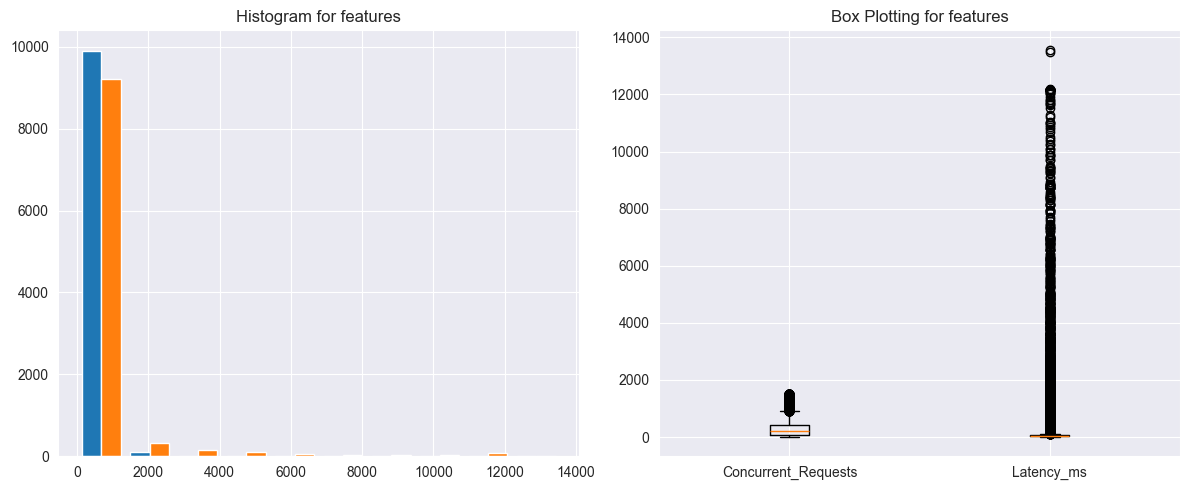

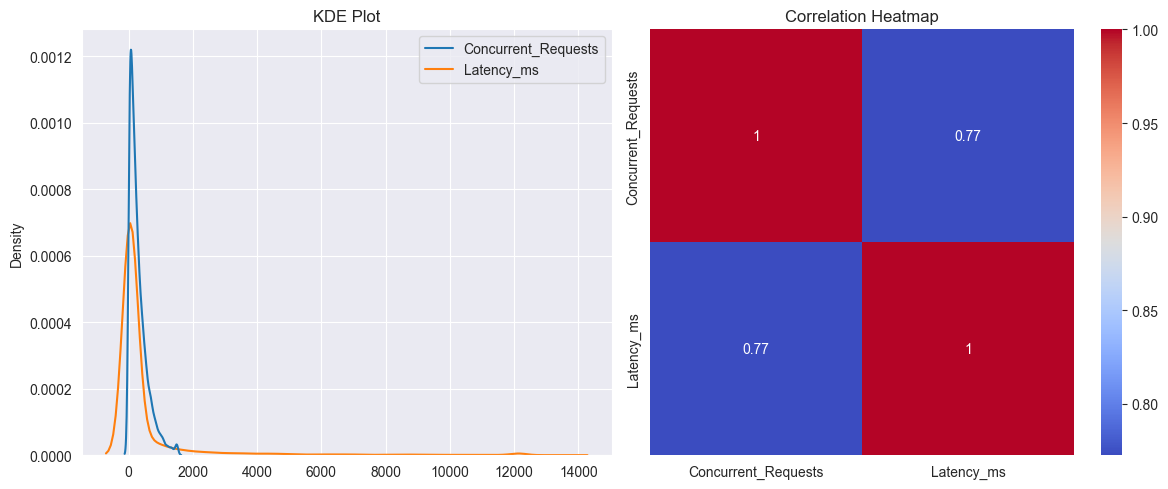

In [7]:
# viewing graphs
# both features have a normal distribution
# both are highly stretched
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df)
axes[0].set_title("Histogram for features")
axes[1].boxplot(df, tick_labels = df.columns)
axes[1].set_title("Box Plotting for features")
plt.tight_layout()

plt.show()

# more useful graphs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(data=df, ax=axes[0])
axes[0].set_title("KDE Plot") 
sns.heatmap(df.corr(), annot=True, ax=axes[1], cmap='coolwarm')
axes[1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [8]:
def task1_regression(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Performs linear and polynomial regression.

    Parameters:
        df (pd.DataFrame): DataFrame containing 'Concurrent_Requests' and 'Latency_ms'.

    Returns:
        Dict[str, Any]:
            - 'linear_model': Trained LinearRegression object.
            - 'linear_metrics': Dict {'mse', 'rmse', 'mae', 'r2'}.
            - 'poly_model': Trained polynomial Pipeline object.
            - 'poly_degree': Best degree (int).
            - 'poly_metrics': Dict {'mse', 'rmse', 'mae', 'r2'}.
    """
    def calculate_metrics(y_true: pd.Series, y_pred: pd.Series) -> Dict[str, Any]:
        """
        Calculates metrics of 'y_true' and 'y_pred'.
        :param y_true: Target values.
        :param y_pred: Predicted values.
        :return: 
            Dict[str, Int]:
                 - 'mse': mean squared error.
                 - 'rmse': root mean squared error.
                 - 'mae': mean absolute error.
                 - 'r2': r2 score.
        """
        return {
            'mse': mean_squared_error(y_true, y_pred), 
            'rmse': root_mean_squared_error(y_true,y_pred),
            'mae': mean_absolute_error(y_true, y_pred),
            'r2': r2_score(y_true, y_pred)
        }
    
    def show_data(X: pd.DataFrame, y: pd.Series, y_pred: pd.Series, label = 'Prediction') -> None:
        """
        Shows data with labels and predictions.
        :param X: Features.
        :param y: Target values.
        :param y_pred: Predicted values.
        :param label: Label for plotting.
        """
        # plotting
        plt.plot(X, y, label='True y', marker='o')
        plt.plot(X, y_pred, label=label, marker='o')
        # labeling
        plt.xlabel('X')
        plt.ylabel('Y and Y_pred')
        # showing with legend
        plt.legend()
        plt.show()
        
    # split on Feature: X and Target: y
    X, y = df[['Concurrent_Requests']], df['Latency_ms']
    # split on train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=True,
        random_state=RANDOM_STATE
    )
    # create a Linear model
    linear_model = LinearRegression()
    
    # create a polynomial_pipeline with PolynomialFeatures and LinearRegression
    # next, we put our polynomial_pipeline in GridSearchCV with a poly_param for training
    polynomial_pipeline = Pipeline([
        ('polynomial_features', PolynomialFeatures()),
        ('linear_regression', LinearRegression())
    ])
    poly_param = {
        'polynomial_features__degree': list(range(2, 6))
    }
    poly_grid_search = GridSearchCV(
        estimator = polynomial_pipeline, 
        param_grid = poly_param, 
        scoring = 'neg_root_mean_squared_error',
    )

    
    # fit on train data linear_model and poly_grid_search
    linear_model.fit(X_train, y_train)
    poly_grid_search.fit(X_train, y_train)
    # poly_model: the best model in poly_grid_search
    poly_model = poly_grid_search.best_estimator_
    
    # make predictions
    linear_predictions = linear_model.predict(X_test)
    poly_predictions = poly_model.predict(X_test)
    
    # plot the data -> we can see that linear_model does not approximate our test data well
    show_data(X_test, y_test, linear_predictions, label = 'linear prediction')
    show_data(X_test, y_test, poly_predictions, label = 'polynomial prediction')

    return {
        'linear_model': linear_model,
        'linear_metrics': calculate_metrics(y_test, linear_predictions),
        'poly_model': poly_model,
        'poly_degree': poly_model.named_steps['polynomial_features'].degree,
        'poly_metrics': calculate_metrics(y_test, poly_predictions)
    }

## Task 2: Classification (70 Points)

### Task 2.1: Data Preprocessing (20 Points)

**Objective:** Clean and prepare the `fraud_detection_student.csv` dataset.

**Requirements:**
1.  **Leakage Removal:** Identify and drop the column that represents data leakage (information available only after fraud determination).
2.  **Feature Engineering:** Create a new binary feature `is_high_risk` from `IP_Address` (1 if starts with `192.168.0`, else 0). Drop original IP column.
3.  **Data Splitting:** Split into Train (80%) and Test (20%) using `random_state=2026` and `stratify`.
4.  **Scaling:** Apply `StandardScaler`.
5.  **Output:** Return the processed numpy arrays.

In [9]:
# reading .csv file
df = pd.read_csv('fraud_detection_student.csv')
df.head()

,Transaction_ID,IP_Address,Transaction_Amount,Hours_Since_Login,Transaction_Status,Is_Fraud
0,TXN_10000,10.96.253.212,45.25,5.61,Completed,0
1,TXN_10001,172.27.192.221,222.46,25.89,Completed,0
2,TXN_10002,172.31.216.227,1325.92,1.68,Completed,0
3,TXN_10003,172.25.213.104,247.81,4.59,Completed,0
4,TXN_10004,10.99.29.196,1577.03,7.40,Blocked,1


In [10]:
# checking Nones -> No Nones
df.isna().sum()

Transaction_ID        0
IP_Address            0
Transaction_Amount    0
Hours_Since_Login     0
Transaction_Status    0
Is_Fraud              0
dtype: int64

In [11]:
# information about features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      10000 non-null  object 
 1   IP_Address          10000 non-null  object 
 2   Transaction_Amount  10000 non-null  float64
 3   Hours_Since_Login   10000 non-null  float64
 4   Transaction_Status  10000 non-null  object 
 5   Is_Fraud            10000 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 468.9+ KB


In [12]:
# split on Feature: X and Target: y
X, y = df.drop('Is_Fraud', axis=1), df['Is_Fraud']
X.head()

,Transaction_ID,IP_Address,Transaction_Amount,Hours_Since_Login,Transaction_Status
0,TXN_10000,10.96.253.212,45.25,5.61,Completed
1,TXN_10001,172.27.192.221,222.46,25.89,Completed
2,TXN_10002,172.31.216.227,1325.92,1.68,Completed
3,TXN_10003,172.25.213.104,247.81,4.59,Completed
4,TXN_10004,10.99.29.196,1577.03,7.40,Blocked


In [13]:
# eval the relationship between Transaction_Status and Is_Fraud
# We see a data leak, because the Transaction_Status column directly tells us the target
pd.crosstab(df["Transaction_Status"], df["Is_Fraud"])

Is_Fraud,0,1
Transaction_Status,,
Blocked,0,119
Chargeback,0,122
Completed,9631,0
Under_Review,0,128


In [14]:
# feature engineering for IP_Address
key = '192.168.0'
X['is_high_risk'] = X['IP_Address'].str.startswith(key).astype(int)
X.drop('IP_Address', axis=1, inplace=True, errors='ignore')
X.head(20)

,Transaction_ID,Transaction_Amount,Hours_Since_Login,Transaction_Status,is_high_risk
0,TXN_10000,45.25,5.61,Completed,0
1,TXN_10001,222.46,25.89,Completed,0
2,TXN_10002,1325.92,1.68,Completed,0
3,TXN_10003,247.81,4.59,Completed,0
4,TXN_10004,1577.03,7.40,Blocked,0
5,TXN_10005,107.67,4.80,Completed,0
6,TXN_10006,147.30,3.70,Completed,0
7,TXN_10007,2160.26,4.22,Completed,0
8,TXN_10008,324.92,1.97,Completed,0
9,TXN_10009,53.41,4.34,Completed,0


In [15]:
# drop Transaction_ID and Transaction_Status
X.drop(['Transaction_ID', 'Transaction_Status'], axis=1, inplace=True, errors='ignore')
X.head(10)

,Transaction_Amount,Hours_Since_Login,is_high_risk
0,45.25,5.61,0
1,222.46,25.89,0
2,1325.92,1.68,0
3,247.81,4.59,0
4,1577.03,7.40,0
5,107.67,4.80,0
6,147.30,3.70,0
7,2160.26,4.22,0
8,324.92,1.97,0
9,53.41,4.34,0


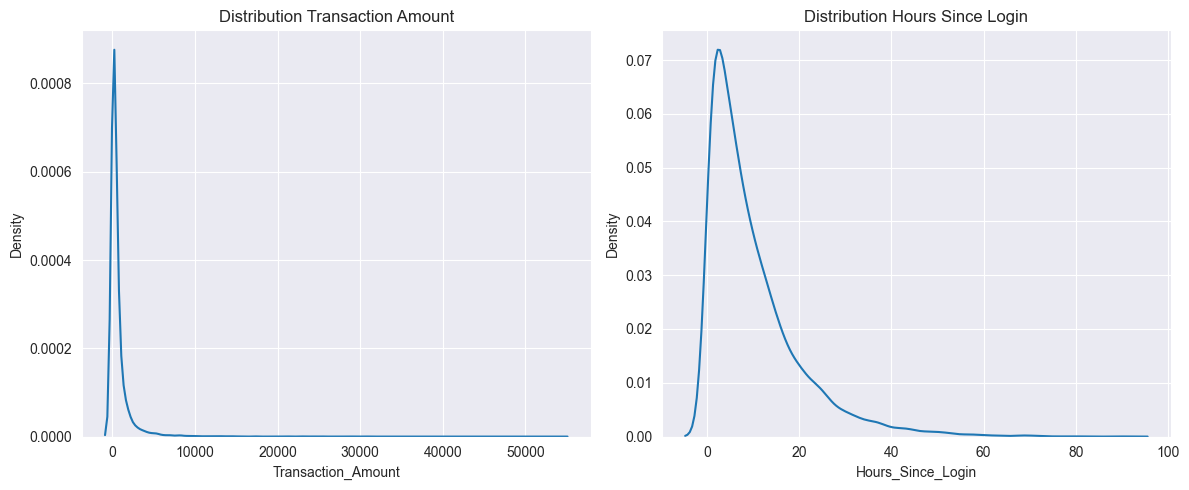

In [16]:
# show the distribution for numerical features -> normal distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(X['Transaction_Amount'], ax=axes[0])
axes[0].set_title('Distribution Transaction Amount')

sns.kdeplot(X['Hours_Since_Login'], ax=axes[1])
axes[1].set_title('Distribution Hours Since Login')

plt.tight_layout()
plt.show()

In [17]:
# standardization
X[['Transaction_Amount', 'Hours_Since_Login']] = StandardScaler().fit_transform(X[['Transaction_Amount', 'Hours_Since_Login']])
X.head()

,Transaction_Amount,Hours_Since_Login,is_high_risk
0,-0.370411,-0.440543,0
1,-0.275752,1.576387,0
2,0.313672,-0.831398,0
3,-0.262211,-0.541986,0
4,0.447805,-0.262520,0


In [18]:
def task2_preprocessing(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Preprocesses fraud data.

    Parameters:
        df (pd.DataFrame): Raw fraud detection dataset.

    Returns:
        Tuple: (X_train_scaled, X_test_scaled, y_train, y_test)
    """
    # split on Feature: X and Target: y
    X, y = df.drop('Is_Fraud', axis=1), df['Is_Fraud']
    
    # drop leakage feature: Transaction_Status and string object id: Transaction_ID 
    X.drop(['Transaction_ID', 'Transaction_Status'], axis=1, inplace=True, errors='ignore')
    
    # new feature: tis_high_risk from IP_Address
    # drop IP_Address
    ip_adress_key = '192.168.0'
    X['is_high_risk'] = X['IP_Address'].astype(str).str.startswith(ip_adress_key).astype(int)
    X.drop('IP_Address', axis=1, inplace=True, errors='ignore')
    
    # split on train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    
    # standardization Transaction_Amount and Hours_Since_Login
    numerical_features = ['Transaction_Amount', 'Hours_Since_Login']
    scaler = StandardScaler()
    # train: fit + transform
    X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
    # test: transform
    X_test[numerical_features] = scaler.transform(X_test[numerical_features])
    
    return X_train.to_numpy(),X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

### Task 2.2: Model Training (30 Points)

**Objective:** Train three classifiers to detect fraud and compare their performance.

**Instructions:**
1.  Use the `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test` variables returned from Task 2.1.
2.  **Logistic Regression:** Use `class_weight='balanced'` to handle class imbalace.
3.  **K-Nearest Neighbors:** Tune `n_neighbors` (3-9) using GridSearchCV. Use `weights='distance'` to handle class imbalace.
4.  **Naive Bayes:** Use `priors=[0.5, 0.5]` to handle class imbalace.
5.  Evaluate all models using **F1-Score at default threshold (0.5)**.
6.  Return all three trained models and their F1 scores.

**Grading Criteria (based on best F1 at default threshold):**
*   F1 ≥ 0.62: Excellent (30/30)
*   F1 ≥ 0.60: Very Good (28/30)
*   F1 ≥ 0.55: Good (25/30)
*   F1 ≥ 0.40: Acceptable (20/30)
*   F1 < 0.40: Poor performance

In [19]:
def task2_train_models(X_train: np.ndarray, X_test: np.ndarray, y_train: np.ndarray, y_test: np.ndarray) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    """
    Trains three classifiers.

    Returns:
        models (Dict): {'logreg': model, 'knn': model, 'nb': model}
        metrics (Dict): {
            'logreg_f1': float,
            'knn_f1': float,
            'nb_f1': float
        }
    """
    # create a Linear model
    logistic_model = LogisticRegression(class_weight='balanced', random_state = RANDOM_STATE)
    
    # create a KNN model and put it in GridSearchCV with a knn_params for training
    knn_params = {
        'n_neighbors': list(range(3, 10)),
    }
    knn_grid_search = GridSearchCV(
        estimator = KNeighborsClassifier(n_neighbors = 5, weights = 'distance'),
        param_grid = knn_params,
        scoring = 'f1'
    )
    # create a Naive Bayes model
    gaussian_model = GaussianNB(priors = [0.5, 0.5])
    
    # fit all models on train data
    logistic_model.fit(X_train, y_train)
    knn_grid_search.fit(X_train, y_train)
    # knn_model: the best model in knn_grid_search
    knn_model = knn_grid_search.best_estimator_
    gaussian_model.fit(X_train, y_train)
    
    # make predictions
    logistic_predictions = logistic_model.predict(X_test)
    knn_predictions = knn_model.predict(X_test)
    gaussian_predictions = gaussian_model.predict(X_test)
    
    # calculate f1 score for each model
    logistic_f1_score = f1_score(y_test, logistic_predictions)
    knn_f1_score = f1_score(y_test, knn_predictions)
    gaussian_f1_score = f1_score(y_test, gaussian_predictions)

    return {
        'logreg': logistic_model, 'knn': knn_model, 'nb': gaussian_model
    }, {
        'logreg_f1': logistic_f1_score, 'knn_f1': knn_f1_score, 'nb_f1': gaussian_f1_score
    }

### Task 2.3: Threshold Tuning for Logistic Regression (20 Points)

**Objective:** Improve Logistic Regression performance through threshold optimization.

**Context:** You may have noticed that Logistic Regression had the lowest F1-score at the default threshold (0.5) but for imbalanced datasets like fraud detection, the decision threshold can significantly impact performance.

**Instructions:**
1.  Take the Logistic Regression model from Task 2.2.
2.  Predict probabilities on the Test Set using `predict_proba`.
3.  Iterate through different thresholds (based on your decision, for example 0.01 to 0.99) to find the one that maximizes F1-Score.
4.  Return the optimal threshold and the improved F1-Score.

**Grading Criteria:**
*   Optimized F1 ≥ 0.65: Excellent (20/20)
*   Optimized F1 ≥ 0.60: Very Good (18/20)
*   Optimized F1 ≥ 0.55: Good (15/20)
*   Optimized F1 ≥ 0.50: Acceptable (10/20)
*   Optimized F1 < 0.50: Poor performance

In [20]:
X_train, X_test, y_train, y_test = task2_preprocessing(pd.read_csv('fraud_detection_student.csv'))
d, _ = task2_train_models(X_train, X_test, y_train, y_test)
logreg = d['logreg']

In [21]:
proba_pred = logreg.predict_proba(X_test)[: , 1]
pred = (proba_pred>0.5).astype(int)
len(pred) - pred.sum(), pred.sum(), pred

(np.int64(1869), np.int64(131), array([0, 0, 0, ..., 0, 0, 0]))

In [22]:
def task2_threshold_tuning(logreg_model: Any, X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:
    """
    Finds the best threshold for Logistic Regression.

    Parameters:
        logreg_model: The trained Logistic Regression model from Task 2.2, you need to re-train it
        X_test, y_test: Test data from Task 2.1

    Returns:
        Dict: {'best_threshold': float, 'optimized_f1': float}
    """
    # make predictions with predict_proba
    predictions = logreg_model.predict_proba(X_test)[:, 1]
    
    # create a list of the thresholds for iterating
    thresholds = np.linspace(0, 1, 1000)
    # initialize best threshold
    best_threshold, optimized_f1 = 0.5,  0
    
    # find the best threshold with the highest f1 score
    for threshold in thresholds:
        score = f1_score(y_test, np.where(predictions > threshold, 1, 0) )
        if score > optimized_f1:
            best_threshold = threshold
            optimized_f1 = score
    
    return {'best_threshold': best_threshold, 'optimized_f1': optimized_f1}
task2_threshold_tuning(logreg, X_test, y_test)

{'best_threshold': np.float64(0.9829829829829829), 'optimized_f1': 0.65625}